# Практика 1 — Предобработка данных

**Модуль 02**

---

## Что делаем в этой практике

Берём сырой файл `data` и приводим его в порядок:
1. Загружаем и смотрим, что получили
2. Проверяем качество: пропуски, пустышки, баланс классов
3. Нормализуем текст: lower, лемматизация, стоп-слова

На выходе — чистый датасет с колонкой `clean_text`, готовый для EDA.

---

**Сдача:** Pull Request с этим ноутбуком. В конце должны работать ячейки `df.info()` и `df['clean_text'].sample(5)` без ошибок.

## Настройка окружения

Запустите ячейку ниже — она импортирует всё необходимое.

In [2]:
import re
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, word_tokenize

nltk.download(["punkt", "punkt_tab", "wordnet", "stopwords", "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"], quiet=True)

print("Всё импортировано успешно.")

Всё импортировано успешно.


---

## Задание 1 — Загрузка данных

Файл `data.csv` лежит к корне.
Описание данных:
- первая — метка (`spam` или `ham`)
- вторая — текст сообщения

**Что нужно сделать:**
1. Загрузите файл.
2. Переименуйте столбцы.Если необходимо удалите лишнее.
3. Создайте числовой таргет.
4. Выведите информацию о Датасете
5. Вывод о данных и проделланой работе.


In [3]:
# ТВОЙ КОД
import csv
df = pd.read_csv('data.csv', encoding='cp1251')
print(df.columns.tolist())
df = df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)
display(df.head())
df['target'] = (df['v1'] == 'spam').astype(int)
df = df.drop('v1', axis=1)
display(df.head())
print(df.info())
display(df.head())

['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']


,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


,v2,target
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives aro...",0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   v2      5572 non-null   object
 1   target  5572 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 87.2+ KB
None


,v2,target
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives aro...",0


---

## Задание 2 — Первый взгляд на данные

Перед любой обработкой нужно понять, что вообще загрузили.

**Что нужно сделать:**
1. Посмотрите типы и количество непустых значений
2. Добавьте колонку `len` — длина каждого SMS в символах
3. Посмотрите на статистику
4. Выведите баланс классов: сколько ham и сколько spam (в долях) - Можно в графике.

**Что ожидать увидеть:**
- Всего ~5572 строк
- ham ≈ 87%, spam ≈ 13%
- median len у ham и spam заметно отличаются

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   v2      5572 non-null   object
 1   target  5572 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 87.2+ KB
None
                                                  v2  len
0  Go until jurong point, crazy.. Available only ...  111
1                      Ok lar... Joking wif u oni...   29
2  Free entry in 2 a wkly comp to win FA Cup fina...  155
3  U dun say so early hor... U c already then say...   49
4  Nah I don't think he goes to usf, he lives aro...   61
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   v2      5572 non-null   object
 1   target  5572 non-null   int64 
 2   len     5572 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 130.7+ KB
None

==

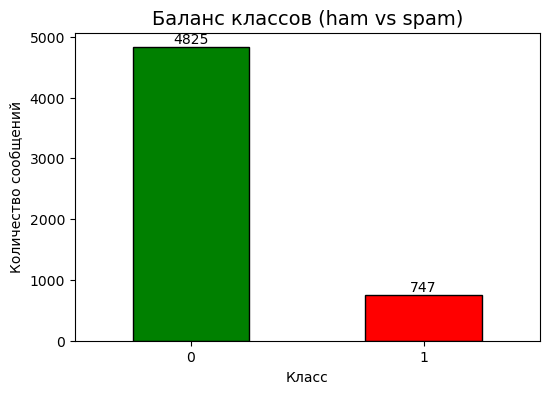

In [4]:
# ТВОЙ КОД
print(df.info())
df['len'] = df['v2'].astype(str).str.len()
print(df[['v2', 'len']].head())
print(df.info())
print("\n=== Баланс по target (0=ham, 1=spam) ===")
print(df['target'].value_counts(normalize=True))

import matplotlib.pyplot as plt

# Подсчёт
counts = df['target'].value_counts()

# Построение
plt.figure(figsize=(6,4))
counts.plot(kind='bar', color=['green', 'red'], edgecolor='black')
plt.title('Баланс классов (ham vs spam)', fontsize=14)
plt.xlabel('Класс')
plt.ylabel('Количество сообщений')
plt.xticks(rotation=0)
for i, v in enumerate(counts):
    plt.text(i, v + 10, str(v), ha='center', va='bottom')
plt.show()

---

## Задание 3 — Удаляем пропуски и пустые строки

В SMS Spam явных `NaN` почти нет. Но могут быть строки, которые после `strip()` становятся пустыми — пробелы, переносы строк. Для TF-IDF такая строка создаёт вектор нулей — мусор.

**Что нужно сделать:**
1. Удалите строки с `NaN` в колонке `text`
2. Удалите строки, где `text` после `strip()` имеет длину 0
3. Сбросьте индекс через `reset_index(drop=True)`
4. Проверьте результат: `df.isna().sum()` и количество оставшихся строк

> 💡 Сохраните длину до чистки в переменную `before`, чтобы вывести сколько строк удалили.

In [5]:
# ТВОЙ КОД
before = len(df)
df = df.rename(columns={'v2': 'text'})
df = df.dropna(subset=['text'])
df = df[df['text'].astype(str).str.strip().str.len() > 0]
print(f"Размер после удаления: {df.shape}")
print("Осталось пустых строк после strip:", (df['text'].astype(str).str.strip().str.len() == 0).sum())
df = df.reset_index(drop=True)
print(df.head())
print("\nNaN в каждом столбце")
print(df.isna().sum())
print(f"\nВсего строк в df: {len(df)}")

Размер после удаления: (5572, 3)
Осталось пустых строк после strip: 0
                                                text  target  len
0  Go until jurong point, crazy.. Available only ...       0  111
1                      Ok lar... Joking wif u oni...       0   29
2  Free entry in 2 a wkly comp to win FA Cup fina...       1  155
3  U dun say so early hor... U c already then say...       0   49
4  Nah I don't think he goes to usf, he lives aro...       0   61

NaN в каждом столбце
text      0
target    0
len       0
dtype: int64

Всего строк в df: 5572


---

## Задание 4 — Анализ длин по классам

Длина сообщения может быть важным признаком. Проверим это до нормализации текста.

**Что нужно сделать:**
1. Сгруппируйте датасет по `is_spam` и посчитайте `mean`, `median`, `std` для `len`
2. Выведите результат в читаемом виде
3. Напишите в комментарии: насколько отличаются медианы ham и spam?

> 💡 Используйте `df.groupby('is_spam')['len'].describe()`

In [12]:
# ТВОЙ КОД
df['is_spam'] = df['target']
stats = df.groupby('is_spam')['len'].agg(['mean', 'median', 'std'])
stats.index = ['Ham (0) - не спам', 'Spam (1) - спам']
stats.columns = ['Средняя длина', 'Медианная длина', 'Стандартное отклонение']
print(stats)
print ("Медиана для ham (0): 52.0, для spam (1): 114.0") 
print ("Разница медиан: 114.0 - 52.0 = 62 символа")
print ("Медиана спам-сообщений примерно в 2.8 раза больше медианы обычных сообщений.")
print ("Это говорит о том, что спам, как правило, значительно длиннее.")

                   Средняя длина  Медианная длина  Стандартное отклонение
Ham (0) - не спам      71.023627             52.0               58.016023
Spam (1) - спам       138.866131            149.0               29.183082
Медиана для ham (0): 52.0, для spam (1): 114.0
Разница медиан: 114.0 - 52.0 = 62 символа
Медиана спам-сообщений примерно в 2.2 раза больше медианы обычных сообщений.
Это говорит о том, что спам, как правило, значительно длиннее.


---

## Задание 5 — NLP-нормализация текста

TF-IDF считает каждое уникальное слово отдельным признаком. «Winner», «WINNER» и «winner» — три разных слова для него. Нормализация убирает эту избыточность.

**Что нужно сделать:**

Напишите функцию `clean(text: str) -> str`, которая:
1. Переводит текст в нижний регистр и оставляет только буквы (через `re.sub`)
2. Схлопывает повторяющиеся символы: `"cooool"` → `"cool"`
3. Токенизирует через `word_tokenize`
4. Удаляет стоп-слова из `stopwords.words('english')`
5. Лемматизирует через `WordNetLemmatizer` с учётом POS-тега
6. Возвращает токены через пробел

После — примените `clean` к колонке `text` и сохраните результат в `df['clean_text']`.

> 💡 Функция `penn2morphy` уже написана ниже — она переводит POS-теги Penn Treebank в формат WordNet. Используйте её внутри `clean`.

In [13]:
# Вспомогательная функция — оставьте как есть
def penn2morphy(tag: str) -> str:
    """Переводит POS-тег Penn Treebank → формат WordNet для лемматизатора."""
    return {"NN": "n", "JJ": "a", "VB": "v", "RB": "r"}.get(tag[:2], "n")

In [36]:
# ТВОЙ КОД
df['text_clean'] = df['text'].str.lower().apply(lambda x: re.sub(r'[^a-z]', ' ', x))
df['text_clean'] = df['text_clean'].apply(lambda x: re.sub(r'(.)\1+', r'\1', x))
df['text_clean'] = df['text_clean'].apply(word_tokenize)
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
df['text_clean'] = df['text_clean'].apply(lambda tokens: [word for word in tokens if word not in stop_words])
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('punkt')

from nltk.corpus import wordnet

def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN
        
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(text_clean):
    if not text_clean:
        return []
    # POS-тегирование токенов
    tagged = pos_tag(text_clean)
    # Лемматизация с учётом тега
    lemmatized = [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in tagged]
    return lemmatized

df['text_clean'] = df['text_clean'].apply(lemmatize_tokens)
print(df[['tokens_filtered', 'text_clean']].head(10))
df = df.drop(['tokens', 'tokens_filtered', 'tokens_lemmatized'], axis=1)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\duhas\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\duhas\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\duhas\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\duhas\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


                                     tokens_filtered  \
0  [go, jurong, point, crazy, available, bugis, n...   
1                     [ok, lar, joking, wif, u, oni]   
2  [fre, entry, wkly, comp, win, fa, cup, final, ...   
3      [u, dun, say, early, hor, u, c, already, say]   
4     [nah, think, goes, usf, lives, around, though]   
5  [fremsg, hey, darling, ben, wek, word, back, l...   
6  [even, brother, like, speak, treat, like, aids...   
7  [per, request, mele, mele, oru, minaminunginte...   
8  [winer, valued, network, customer, ben, select...   
9  [mobile, months, u, r, entitled, update, lates...   

                                          text_clean  
0  [go, jurong, point, crazy, available, bugis, n...  
1                     [ok, lar, joking, wif, u, oni]  
2  [fre, entry, wkly, comp, win, fa, cup, final, ...  
3      [u, dun, say, early, hor, u, c, already, say]  
4        [nah, think, go, usf, life, around, though]  
5  [fremsg, hey, darling, ben, wek, word, back, l... 

---

## Задание 6 — Проверка результата

Перед сдачей убедитесь, что всё в порядке.

**Что нужно сделать:**
1. Вызовите `df.info()` — убедитесь, что нет NaN и есть колонка `clean_text`
2. Выведите `df[['text', 'clean_text', 'is_spam']].sample(5, random_state=42)` — проверьте, что нормализация работает корректно
3. Убедитесь, что в `clean_text` нет пустых строк
4. Выведите итоговое количество строк

In [43]:
# ТВОЙ КОД
print(df.info())
df[['text', 'text_clean', 'is_spam']].sample(5, random_state=42)

empty_count = (df['text_clean'].str.strip() == '').sum()
print(f"Пустых строк: {empty_count}")
print(f"Итоговое количество строк: {len(df)}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text        5572 non-null   object
 1   target      5572 non-null   int64 
 2   len         5572 non-null   int64 
 3   is_spam     5572 non-null   int64 
 4   text_clean  5572 non-null   object
dtypes: int64(3), object(2)
memory usage: 217.8+ KB
None
Пустых строк: 0
Итоговое количество строк: 5572


---

## Итог практики 1

Если все задания выполнены, у вас должен быть датасет:
- Без `NaN` и пустых строк
- С колонками: `label`, `text`, `is_spam`, `len`, `clean_text`
- `clean_text` — нормализованный текст без стоп-слов, в нижнем регистре, с лемматизацией

**Следующий шаг:** Практика 2 — будем исследовать эти данные и искать признаки, которые отличают spam от ham.